Drift Analysis 1 (Verbalized Sampling)
===
- Analysis of Experiment 1 (paraphrasing chains)
- Descriptives (drift trajetories, drift delta distributions, correlations between seed and final message)
- Identifying seed sentence properties most predictive of drift using mixed effects modeling

See **Analysis 2** for attractor modeling.

In [1]:
import jupyter_black

jupyter_black.load()

## 0. Imports and Data

In [17]:
import os
import json

# import glob
# import pickle
# import sys
from pathlib import Path
from collections import defaultdict
from functools import partial

# from datetime import datetime, UTC

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# from scipy.stats import sem, t
# from scipy import stats

# from echochain.utils import find_element_with_hop_value, parse_config, get_data_dir
from echochain.utils import get_data_dir

# from echochain.stats_utils import has_chain
# from echochain.icc_utils import compute_icc, interpret_icc
# from echochain.plot_utils import ci95

# import publication_outputs.figures as F
# from publication_outputs.tables import TableSpec, write_table

# from transformers import logging
# logging.set_verbosity_error()  # silence warnings (e.g., "Some weights of the model checkpoint at microsoft/deberta-large-mnli were not used when initializing DebertaForSequenceClassification: ['config']")

ANALYSIS_NAME = "descriptives_vs"
SUB_PATH = "vs_weighted"

# Paths/config
DATA_DIR = get_data_dir()
LOGS_DIR = Path(DATA_DIR, "data", "echodrift_logs")
STATS_DIR = Path(DATA_DIR, "data", "echodrift_stats")
STATS_DIR = Path(DATA_DIR, "data", "echodrift_stats", SUB_PATH)


os.makedirs(STATS_DIR, exist_ok=True)
SHARD_ROOT = STATS_DIR / "shards"
SHARD_ROOT.mkdir(parents=True, exist_ok=True)
EXPORT_PATH_PUB = Path(DATA_DIR, "pub", ANALYSIS_NAME)
EXPORT_PATH_PUB.mkdir(parents=True, exist_ok=True)
# Versioning for metric changes
METRICS_VERSION = "v1.0.0"

# MSG_FILE = Path(DATA_DIR, "seed_sentences_50.json")
MSG_FILE = Path("seed_sentences_50.json")  # because currently under git control

# Which configs/models to include in paper figures/tables now (pilot)
# Set to None to include all available configs/models
# CHOSEN_MODELS = None # ["gpt-4.1-nano"]  # adjust or set to None
# CHOSEN_CONFIGS = None # ["temp0.8_topp0.5"]  # adjust or set to None

# Nested dict helpers
level_1 = partial(defaultdict, list)
level_2 = partial(defaultdict, level_1)

with open(MSG_FILE, "r") as fp:
    seed_sentences = json.load(fp)

crit_list = [
    "length",
    "domain",
    "syntax",
    "entities",
    "polarity",
    "tense",
]

axes_list = [
    "valence_neg_to_pos",
    "tone_neutral_to_intense",
    "moderate_to_extreme",
    "factual_to_narrative",
    "abstract_to_concrete",
]

metrics_list = [
    "len",
    "delta_len",
    "ratio_len",
    "jaccard",
    "k_unique",
    "cosine",
    "entail_ab",
    "entail_ba",
    "entail_consistent",
    "entity_f1",
    "triple_f1",
    "role_swap",
]

INDEX_COLS = [
    "model",
    "config",
    "temperature",
    "top_p",
    "msg_id",
    "chain",
    "length_tk",
]

df = pd.read_csv(STATS_DIR / "metrics_cumulative_long.csv")
try:
    df_axis = pd.read_csv(STATS_DIR / "axis_cumulative_long.csv")
except Exception as e:
    print(e)

[Errno 2] No such file or directory: '/home/user/data_export/echo-chain/data/echodrift_stats/vs_weighted/axis_cumulative_long.csv'


### 0.1. Add extra information to data
- hop 0
- length
- categories
- short seed sentence
- axes

In [19]:
# hop 0

df_0 = df.loc[df["hop"] == 1].copy()
df_0["value"] = np.nan

df_0["hop"] = 0
df_0.loc[
    df_0["metric"].isin(
        [
            "ratio_len",
            "jaccard",
            "cosine",
            "entail_ab",
            "entail_ba",
            "entail_consistent",
        ]
    ),
    "value",
] = 1.0

df_0.loc[
    df_0["metric"].isin(
        [
            "delta_len",
            "role_swap",
            "entity_f1",
            "triple_f1",
        ]
    ),
    "value",
] = 0

df_0.loc[
    df_0["metric"].isin(
        [
            "k_unique",
        ]
    ),
    "value",
] = 1

df = pd.concat([df, df_0], sort=False)
del df_0

# axis

df_axis = df_axis.melt(
    id_vars=[
        "model",
        "config",
        "msg_id",
        "chain",
        "hop",
        "kind",
        "temperature",
        "top_p",
    ],
    value_vars=axes_list,
    var_name="metric",
).copy()

df = pd.concat([df, df_axis], sort=False)
del df_axis


# add length, categories and short see
def append_len(df, seed_len):
    df_extra = df.loc[df["metric"] == "delta_len"].copy()
    df_extra["metric"] = "len"
    df_extra["value"] = df_extra["value"] + df_extra["msg_id"].map(seed_len)
    df = pd.concat([df, df_extra], sort=False)
    return df


def add_category_cols(df, seed_categories):
    return df.merge(
        pd.DataFrame(seed_categories)
        .T.reset_index()
        .rename(columns={"index": "msg_id"}),
        how="left",
        on="msg_id",
    )


def add_seed_short(df, seed_sentences_short):
    df["seed_short"] = df["msg_id"].map(seed_sentences_short)
    return df


seed_len = {
    "MSG_" + str(i + 1).zfill(3): x["length_tk"]
    for i, x in enumerate(seed_sentences["labels"])
}

df = append_len(df, seed_len)

seed_categories = {
    "MSG_" + str(i + 1).zfill(3): x for i, x in enumerate(seed_sentences["labels"])
}

df = add_category_cols(df, seed_categories)

seed_sentences_short = {
    "MSG_" + str(i + 1).zfill(3): x[:25] + "..."
    for i, x in enumerate(seed_sentences["sentences"])
}

df = add_seed_short(df, seed_sentences_short)

NameError: name 'df_axis' is not defined

### 0.2. Create wide table with differences between seed and final message

In [4]:
def create_wide_df(df, axes_list, crit_list, metrics_list, index_cols=INDEX_COLS):
    last_hop = int(df["hop"].max())

    mask = df["hop"].isin([0, last_hop])
    df_filtered = df[mask].copy()

    pivoted = df_filtered.pivot_table(
        index=index_cols + crit_list, columns=["hop", "metric"], values="value"
    )

    pivoted.columns = [f"{metric}_{hop}" for hop, metric in pivoted.columns]

    result_cols = []
    all_vars = metrics_list + axes_list

    for var in all_vars:
        col_0 = f"{var}_0"
        col_last = f"{var}_{last_hop}"

        if col_0 in pivoted.columns and col_last in pivoted.columns:
            new_initial = f"initial_{var}"
            new_last = f"last_{var}"
            new_diff = f"d_{var}"

            pivoted[new_initial] = pivoted[col_0]
            pivoted[new_last] = pivoted[col_last]
            pivoted[new_diff] = pivoted[col_last] - pivoted[col_0]
            result_cols.extend([new_initial, new_last, new_diff])

    return pivoted[result_cols].reset_index()


df_wide = create_wide_df(df, axes_list, crit_list, metrics_list)

## 1. Visualize Drift

### 1.1. Mean trajectories grouped by decoding parameters

In [5]:
def plot_mean_traj(df, metric, ylim=None):

    fig, axs = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

    axs[0] = sns.lineplot(
        data=df.loc[df["metric"] == metric].sort_values("config"),
        x="hop",
        y="value",
        ax=axs[0],
    )
    axs[0].set_title("Mean trajectory")

    axs[1] = sns.lineplot(
        data=df.loc[df["metric"] == metric],
        x="hop",
        y="value",
        hue="temperature",
        palette="colorblind",
        ax=axs[1],
    )
    axs[1].set_title("Mean trajectories by temperature")

    axs[2] = sns.lineplot(
        data=df.loc[df["metric"] == metric],
        x="hop",
        y="value",
        hue="top_p",
        palette="colorblind",
        ax=axs[2],
    )
    axs[2].set_title("Mean trajectories by top-$p$")

    axs[0].set_ylabel(metric)
    axs[1].set_ylabel(None)
    axs[2].set_ylabel(None)

    # for similarity metrics: y range at least 0.5-1
    if ylim:
        [ax.set_ylim(ylim[0], ylim[1]) for ax in axs]

    elif metric in ["cosine", "jaccard", "entail_consistent", "entail_ab", "entail_ba"]:
        [ax.set_ylim(0.5, 1.0) for ax in axs if ax.get_ylim()[0] > 0.5]
        # [ax.set_ylim(ax.get_ylim()[0], 1.0) for ax in axs]

    fig.tight_layout()

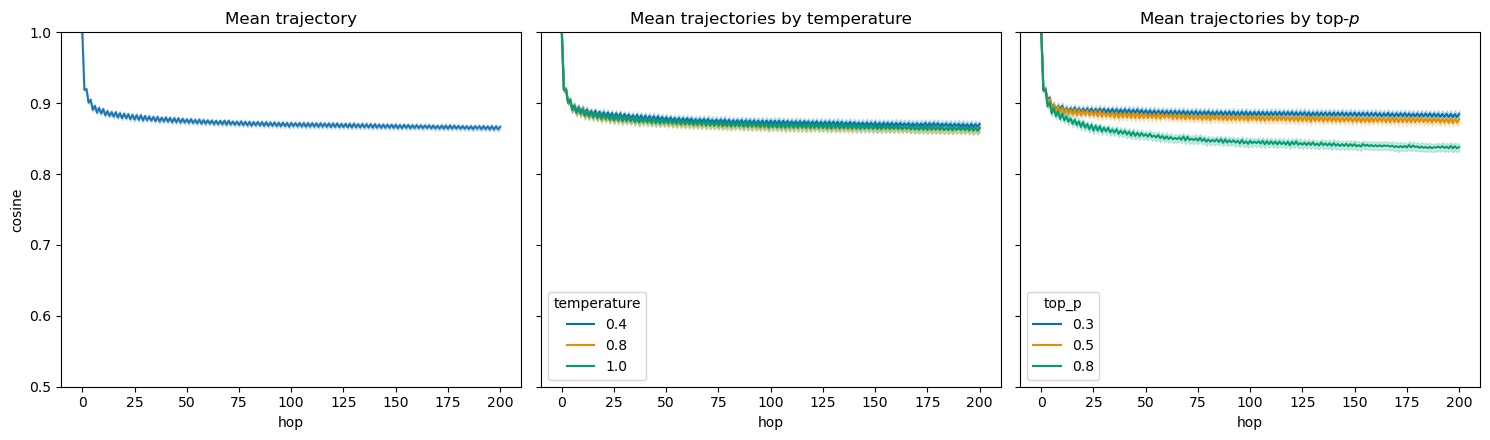

In [6]:
plot_mean_traj(df, "cosine")

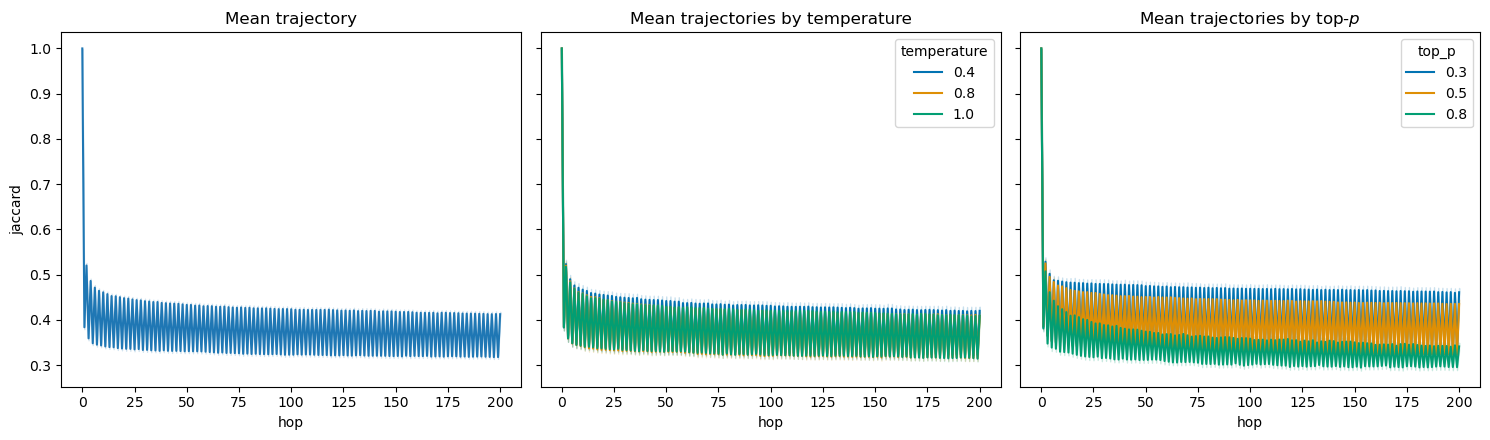

In [7]:
plot_mean_traj(df, "jaccard")

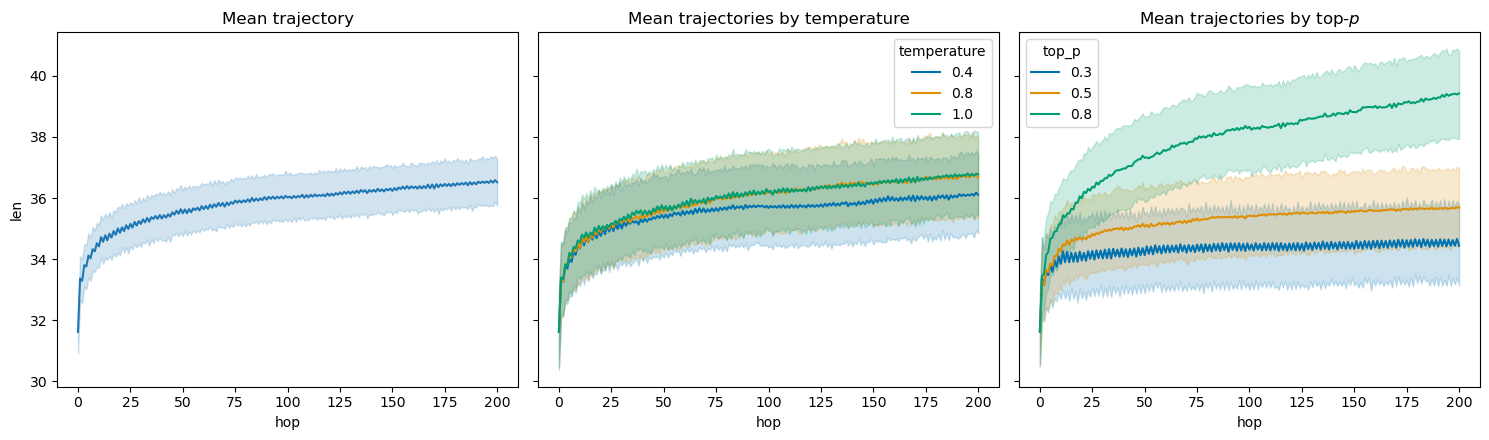

In [8]:
plot_mean_traj(df, "len")

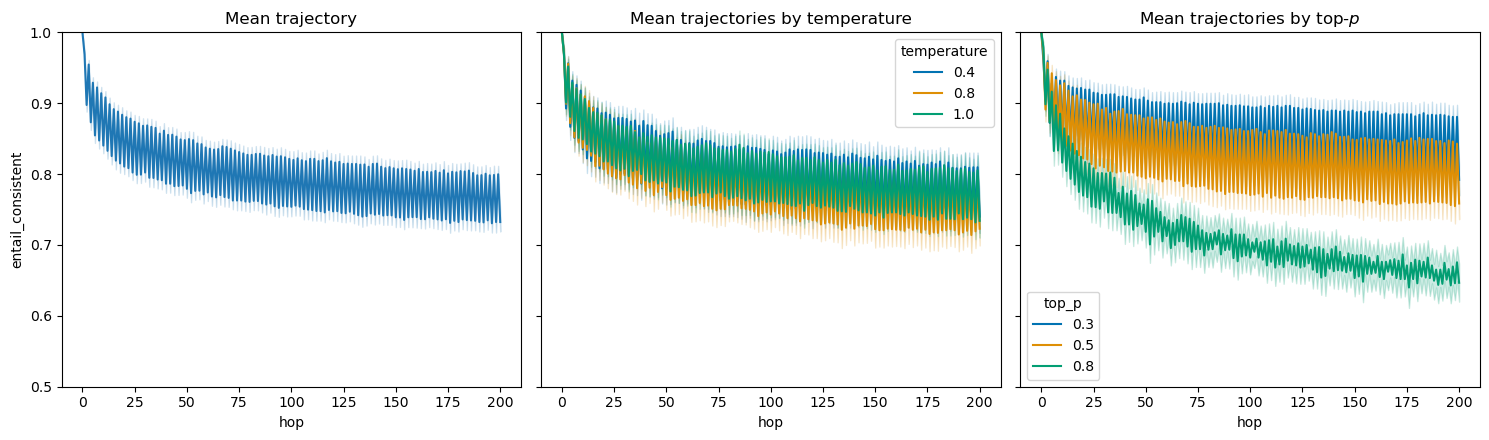

In [9]:
plot_mean_traj(df, "entail_consistent")

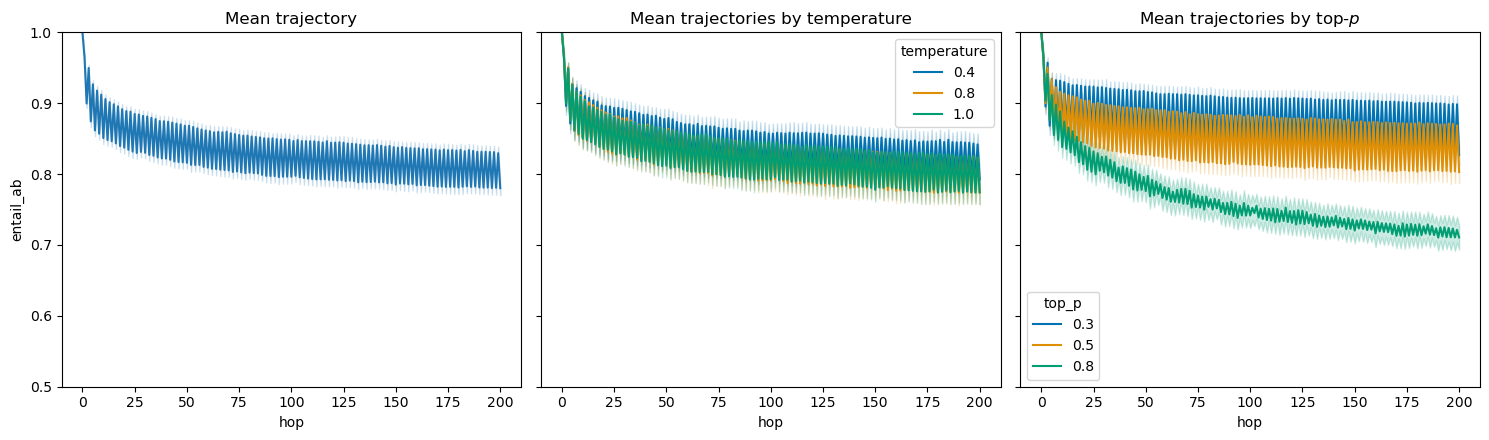

In [10]:
plot_mean_traj(df, "entail_ab")

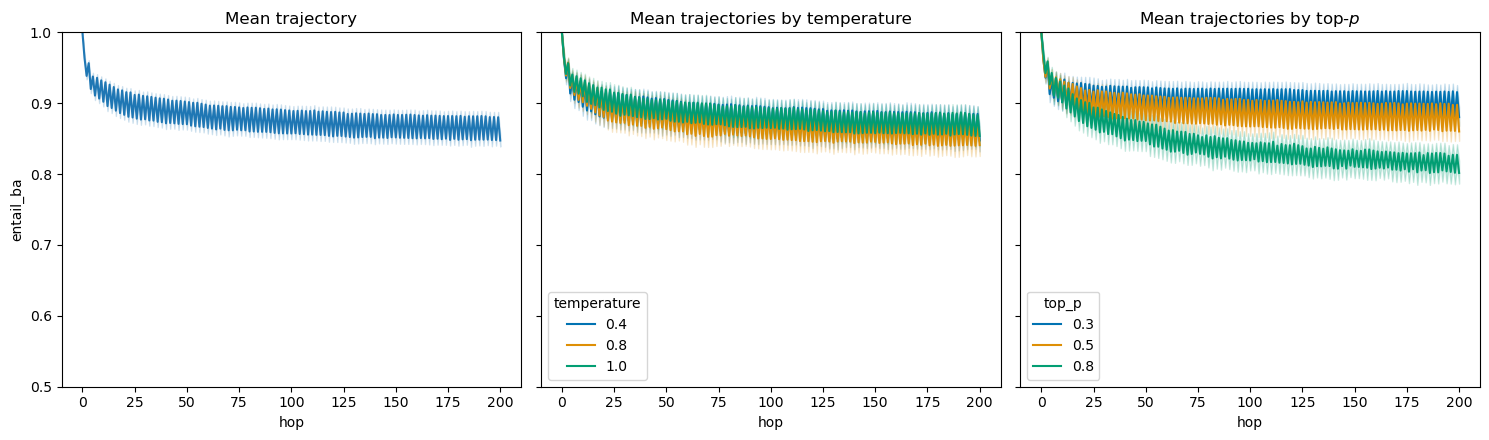

In [11]:
plot_mean_traj(df, "entail_ba")

exactly the same data as in `analysis_01.ipynb`!

KeyboardInterrupt: 

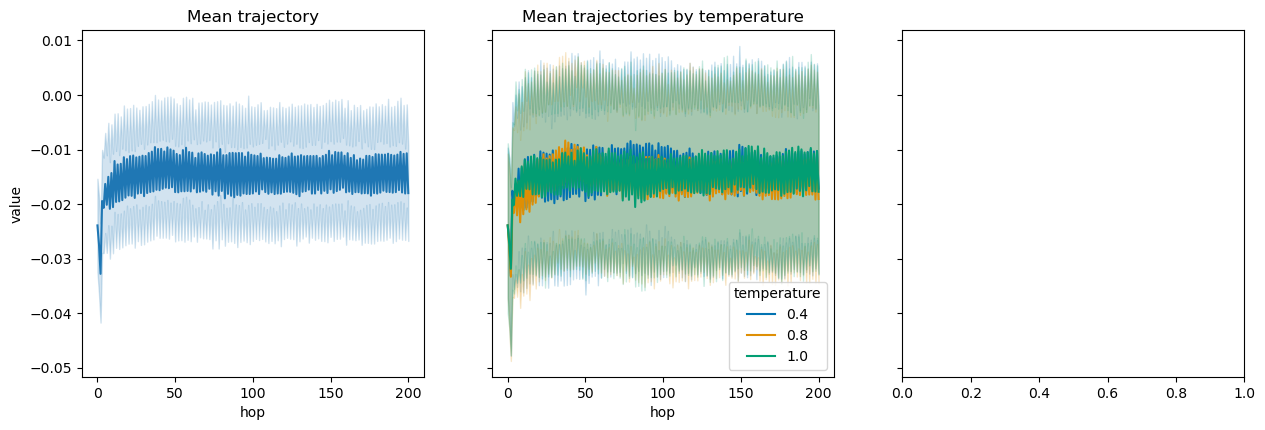

In [12]:
plot_mean_traj(df, "valence_neg_to_pos", ylim=(-0.5, 0.5))

In [ ]:
plot_mean_traj(df, "tone_neutral_to_intense", ylim=(-0.5, 0.5))

In [ ]:
plot_mean_traj(df, "abstract_to_concrete", ylim=(-0.5, 0.5))

In [ ]:
plot_mean_traj(df, "factual_to_narrative", ylim=(-0.5, 0.5))

In [ ]:
plot_mean_traj(df, "moderate_to_extreme", ylim=(-0.5, 0.5))

When do unique new sentences appear? Creativity?

In [ ]:
plot_mean_traj(df, "k_unique")

### 1.2. Mean trajectories grouped by criterion categories

In [ ]:
metric = "valence_neg_to_pos"

fig, axs = plt.subplots(2, 3, figsize=(15, 9), sharey=True, sharex=True)

for i, ax in enumerate(axs.flatten()):
    sns.lineplot(
        data=df.loc[df["metric"] == metric],
        x="hop",
        y="value",
        hue=crit_list[i],
        palette="colorblind",
        ax=ax,
    )

    ax.set_title(metric)

fig.tight_layout()

In [ ]:
metric = "tone_neutral_to_intense"

fig, axs = plt.subplots(2, 3, figsize=(15, 9), sharey=True, sharex=True)

for i, ax in enumerate(axs.flatten()):
    sns.lineplot(
        data=df.loc[df["metric"] == metric],
        x="hop",
        y="value",
        hue=crit_list[i],
        palette="colorblind",
        ax=ax,
    )

    ax.set_title(metric)

fig.tight_layout()

In [ ]:
metric = "abstract_to_concrete"

fig, axs = plt.subplots(2, 3, figsize=(15, 9), sharey=True, sharex=True)

for i, ax in enumerate(axs.flatten()):
    sns.lineplot(
        data=df.loc[df["metric"] == metric],
        x="hop",
        y="value",
        hue=crit_list[i],
        palette="colorblind",
        ax=ax,
    )

    ax.set_title(metric)

fig.tight_layout()

In [ ]:
metric = "factual_to_narrative"

fig, axs = plt.subplots(2, 3, figsize=(15, 9), sharey=True, sharex=True)

for i, ax in enumerate(axs.flatten()):
    sns.lineplot(
        data=df.loc[df["metric"] == metric],
        x="hop",
        y="value",
        hue=crit_list[i],
        palette="colorblind",
        ax=ax,
    )

    ax.set_title(metric)

fig.tight_layout()

In [ ]:
metric = "moderate_to_extreme"

fig, axs = plt.subplots(2, 3, figsize=(15, 9), sharey=True, sharex=True)

for i, ax in enumerate(axs.flatten()):
    sns.lineplot(
        data=df.loc[df["metric"] == metric],
        x="hop",
        y="value",
        hue=crit_list[i],
        palette="colorblind",
        ax=ax,
    )

    ax.set_title(metric)

fig.tight_layout()

In [ ]:
metric = "k_unique"

fig, axs = plt.subplots(2, 3, figsize=(15, 9), sharey=True, sharex=True)

for i, ax in enumerate(axs.flatten()):
    sns.lineplot(
        data=df.loc[df["metric"] == metric],
        x="hop",
        y="value",
        hue=crit_list[i],
        palette="colorblind",
        ax=ax,
    )

    ax.set_title(metric)

fig.tight_layout()

In [ ]:
metric = "len"


sns.lineplot(
    data=df.loc[df["metric"] == metric].sort_values("config"),
    x="hop",
    y="value",
    hue="length_tk",
    palette="viridis",
)
plt.title("Mean trajectories by initial length")

plt.ylabel(metric)

## 2. Visualize distributions of differences (final-seed)
- Violinplots

In [ ]:
df_wide_melted = df_wide.melt(
    id_vars=INDEX_COLS + crit_list,
    value_vars=[f"d_{ax}" for ax in axes_list],
    var_name="metric",
).copy()

sns.violinplot(data=df_wide_melted, x="metric", y="value", inner="quartiles")
plt.grid()
plt.ylabel("Difference in axis value")

In [ ]:
df_wide_melted = df_wide.melt(
    id_vars=INDEX_COLS + crit_list,
    value_vars="d_len",
    var_name="metric",
).copy()


sns.violinplot(data=df_wide_melted, x="metric", y="value", inner="quartiles")
plt.ylabel("Difference in length")
plt.grid()

### 2.1. Visualizing similarity measures

In [ ]:
df_wide_melted = df_wide.melt(
    id_vars=INDEX_COLS + crit_list,
    value_vars=[
        "last_cosine",
        "last_jaccard",
        "last_entail_ab",
        "last_entail_ba",
        "last_entail_consistent",
    ],
    var_name="metric",
).copy()

sns.violinplot(data=df_wide_melted, x="metric", y="value", inner="quartiles")
plt.ylabel("Similarity of last hop with seed hop")

plt.grid()

## 3. Visualize relationships seed vs. final messages

- Scatter/Regplots

In [ ]:
df_wide.columns

In [ ]:
metric = "len"
sns.regplot(
    data=df_wide,
    x=f"initial_{metric}",
    y=f"last_{metric}",
    scatter_kws=dict(alpha=0.3),
)

In [ ]:
metric = "valence_neg_to_pos"
sns.regplot(
    data=df_wide, x=f"initial_{metric}", y=f"last_{metric}", scatter_kws=dict(alpha=0.3)
)

In [ ]:
metric = "moderate_to_extreme"
sns.regplot(
    data=df_wide, x=f"initial_{metric}", y=f"last_{metric}", scatter_kws=dict(alpha=0.3)
)

In [ ]:
metric = "tone_neutral_to_intense"
sns.regplot(
    data=df_wide, x=f"initial_{metric}", y=f"last_{metric}", scatter_kws=dict(alpha=0.3)
)

In [ ]:
metric = "factual_to_narrative"
sns.regplot(
    data=df_wide, x=f"initial_{metric}", y=f"last_{metric}", scatter_kws=dict(alpha=0.3)
)

In [ ]:
metric = "abstract_to_concrete"
sns.regplot(
    data=df_wide, x=f"initial_{metric}", y=f"last_{metric}", scatter_kws=dict(alpha=0.3)
)

In [ ]:
df_wide[
    [
        "initial_len",
        "initial_valence_neg_to_pos",
        "initial_tone_neutral_to_intense",
        "initial_moderate_to_extreme",
        "initial_factual_to_narrative",
        "initial_abstract_to_concrete",
    ]
].corr().round(2)

In [ ]:
df_wide[
    [
        "initial_len",
        "initial_valence_neg_to_pos",
        "initial_tone_neutral_to_intense",
        "initial_moderate_to_extreme",
        "initial_factual_to_narrative",
        "initial_abstract_to_concrete",
    ]
].corr().round(2)

In [ ]:
df_wide[
    [
        "last_len",
        "last_valence_neg_to_pos",
        "last_tone_neutral_to_intense",
        "last_moderate_to_extreme",
        "last_factual_to_narrative",
        "last_abstract_to_concrete",
    ]
].corr().round(2)

In [ ]:
sns.pairplot(
    df_wide[
        [
            "initial_len",
            "last_len",
            "initial_valence_neg_to_pos",
            "last_valence_neg_to_pos",
            "initial_tone_neutral_to_intense",
            "last_tone_neutral_to_intense",
            "initial_moderate_to_extreme",
            "last_moderate_to_extreme",
            "initial_factual_to_narrative",
            "last_factual_to_narrative",
            "initial_abstract_to_concrete",
            "last_abstract_to_concrete",
        ]
    ]
)

## 4. Visualize difference along axes between finital and final message using spider plots

Good examples:

```python
msg_id = "MSG_002"
config = "temp0.8_topp0.5"

msg_id = "MSG_011"
config = "temp0.8_topp0.5"

msg_id = "MSG_002"
config = "temp1.0_topp0.8"
chain_id = 3

msg_id = "MSG_013"
config = "temp0.8_topp0.5"
chain_id = 4

msg_id = "MSG_014"
config = "temp0.8_topp0.5"
chain_id = 4

msg_id = "MSG_022"
config = "temp0.8_topp0.5"
chain_id = 4
chain_id = 7

model = "gpt-4.1-nano"
msg_id = "MSG_022"
config = "temp0.8_topp0.8"
chain_id = 1

```



In [ ]:
import glob

In [ ]:
with open(MSG_FILE, "r") as fp:
    seed_sentences = json.load(fp)

SKIP_CRIT = ["length_tk"]
CRITERIA = [c for c in seed_sentences["labels"][0].keys() if c not in SKIP_CRIT]

# Collect logs
data = defaultdict(level_2)
models = [d for d in os.listdir(LOGS_DIR) if (LOGS_DIR / d).is_dir()]

for model in models:
    configs = [
        d for d in os.listdir(LOGS_DIR / model) if (LOGS_DIR / model / d).is_dir()
    ]
    for config in configs:
        log_dir = LOGS_DIR / model / config
        files = sorted(glob.glob(str(log_dir / "*.json")))
        for f in files:
            with open(f, "r", encoding="utf-8") as fp:
                chain = json.load(fp)
            msg_id = Path(f).stem[:7]  # e.g., 'MSG_001'
            data[model][config][msg_id].append(chain)

        total_chains = sum(len(v) for v in data[model][config].values())
        print(
            f"{model} {config}: {len(data[model][config])} messages; {total_chains} chains total."
        )

In [ ]:
model = "gpt-4.1-nano"
msg_id = "MSG_022"
config = "temp0.8_topp0.8"
chain_id = 1
initial_txt = data[model][config][msg_id][chain_id][0]["text"]
final_txt = data[model][config][msg_id][chain_id][200]["text"]


print(initial_txt)
print()
print(final_txt)

(
    initial_valence_neg_to_pos,
    last_valence_neg_to_pos,
    initial_tone_neutral_to_intense,
    last_tone_neutral_to_intense,
    initial_moderate_to_extreme,
    last_moderate_to_extreme,
    initial_factual_to_narrative,
    last_factual_to_narrative,
    initial_abstract_to_concrete,
    last_abstract_to_concrete,
) = df_wide.loc[
    (df_wide["model"] == model)
    & (df_wide["config"] == config)
    & (df_wide["chain"] == chain_id + 1)
    & (df_wide["msg_id"] == msg_id),
    [
        "initial_valence_neg_to_pos",
        "last_valence_neg_to_pos",
        "initial_tone_neutral_to_intense",
        "last_tone_neutral_to_intense",
        "initial_moderate_to_extreme",
        "last_moderate_to_extreme",
        "initial_factual_to_narrative",
        "last_factual_to_narrative",
        "initial_abstract_to_concrete",
        "last_abstract_to_concrete",
    ],
].values[
    0
]

In [ ]:
from matplotlib.projections.polar import PolarAxes
from matplotlib.projections import register_projection
import matplotlib.spines as spines
import matplotlib.path as path
import textwrap
import publication_outputs.figures as F


F.setup_style(
    profile="nature",
    use_tex=False,
    base_font=7,
    title_font_delta=0,
    major_ticks=False,
    minor_ticks=False,
    rc_extra={"axes.axisbelow": True},
)

out_path_base = EXPORT_PATH_PUB / "spider_plot"


def radar_factory(num_vars, frame="circle"):
    theta = np.linspace(0, 2 * np.pi, num_vars, endpoint=False)

    class RadarAxes(PolarAxes):
        name = "radar"
        RESOLUTION = 1

        def fill(self, *args, closed=True, **kwargs):
            return super().fill(closed=closed, *args, **kwargs)

        def plot(self, *args, **kwargs):
            lines = super().plot(*args, **kwargs)
            for line in lines:
                self._close_line(line)
            return lines

        def _close_line(self, line):
            x, y = line.get_data()
            if x[0] == x[-1] and y[0] == y[-1]:
                return
            x = np.concatenate((x, [x[0]]))
            y = np.concatenate((y, [y[0]]))
            line.set_data(x, y)

        def set_varlabels(self, labels):
            self.set_thetagrids(np.degrees(theta), labels)

        def _gen_axes_patch(self):
            if frame == "circle":
                return super()._gen_axes_patch()
            elif frame == "polygon":
                return plt.Polygon(unit_poly_verts(theta), closed=True, edgecolor="k")

        # === ADD THIS METHOD TO FIX THE 4-INPUT CLIPPING ===
        def _gen_axes_spines(self):
            if frame == "circle":
                return super()._gen_axes_spines()

            # This forces the outer spine/border to exactly match the polygon's path
            spine_type = "circle"
            verts = unit_poly_verts(theta)
            verts.append(verts[0])  # Close the path
            path_obj = path.Path(verts)

            sp = spines.Spine(self, spine_type, path_obj)
            sp.set_transform(self.transAxes)
            return {"polar": sp}

        def draw(self, renderer):
            if frame == "polygon":
                gridlines = self.yaxis.get_gridlines()
                for gl in gridlines:
                    gl.get_path()._interpolation_steps = num_vars
            super().draw(renderer)

    def unit_poly_verts(theta):
        x0, y0, r = [0.5] * 3
        verts = []
        for t in theta:
            verts.append((r * np.cos(t) + x0, r * np.sin(t) + y0))
        return verts

    register_projection(RadarAxes)
    return theta


def figure_semantic_axes_radar(
    seed_scores,
    hop_scores,
    initial_txt=None,
    final_txt=None,
    wrap_len=30,
    width_mm=66,
    height_mm=40,
    labels=["Valence", "Intensity", "Extremity", "Factuality", "Abstractness"],
):

    # Wrap the labels
    label_initial = "\n".join(textwrap.wrap(initial_txt, width=wrap_len))
    label_final = "\n".join(textwrap.wrap(final_txt, width=wrap_len))
    N = len(labels)
    theta = radar_factory(N, frame="circle")
    fig, (ax,) = F.make_fig(
        width_mm=width_mm,
        height_mm=height_mm,
        constrained=False,
        subplot_kw=dict(projection="radar"),
    )
    # fig.subplots_adjust(left=0.42, right=0.98, bottom=0.12, top=0.95)

    ax.set_ylim(-1, 1)  # Ensure the scale is fixed
    ax.set_rorigin(-1)  # Sets the center point of the circle to -1
    ax.set_rgrids([-1, -0.5, 0, 0.5, 1])  # Clearer grid markings
    ax.set_yticklabels([])  # This hides the numbers on those rings
    # -----------------------------------------

    ax.set_varlabels(labels)
    # ax.set_title(
    #     "Semantic Axis Profiles",
    #     position=(0.5, 1.1),
    #     ha="center",
    # )
    ax.set_varlabels(labels)

    # Plot seed
    line1 = ax.plot(
        theta,
        seed_scores,
        color="gray",
        linewidth=1,
        label=("Input" if initial_txt is None else f'''Input:\n\n"{label_initial}"'''),
    )
    ax.fill(theta, seed_scores, color="gray", alpha=0.25)

    # Plot average after N hops
    line2 = ax.plot(
        theta,
        hop_scores,
        color="salmon",
        linewidth=1,
        label=("Output" if final_txt is None else f'''Output:\n\n"{label_final}"'''),
    )
    ax.fill(theta, hop_scores, color="salmon", alpha=0.25)

    # Legend
    ax.legend(
        loc="center left",
        bbox_to_anchor=(1.2, 0.5),
        frameon=False,
        ncol=1,
        handletextpad=1.0,
        labelspacing=3.0,
        fontsize=5,
    )
    plt.show()
    plt.close()
    return fig


fig = figure_semantic_axes_radar(
    [
        initial_valence_neg_to_pos,
        initial_tone_neutral_to_intense,
        initial_moderate_to_extreme,
        -1 * initial_factual_to_narrative,
        -1 * last_abstract_to_concrete,
    ],
    [
        last_valence_neg_to_pos,
        last_tone_neutral_to_intense,
        last_moderate_to_extreme,
        -1 * last_factual_to_narrative,
        -1 * initial_abstract_to_concrete,
    ],
    initial_txt,
    final_txt,
    width_mm=66,
    height_mm=30,
)

F.save(fig, out_path_base, formats=("pdf", "png"), dpi_png=600, tight=True)
F.file_dimensions(EXPORT_PATH_PUB, out_path_base.name, print_only=True)

---
Temporary content: Same example for norm chains (without data, only illustration). 

Move this part later into analysis_2_norms.ipynb

In [ ]:
out_path_base = EXPORT_PATH_PUB / "spider_plot_norms"

# assumes a -1,1 range

initial_norm = r"""Alex sees a coworker taking pens." $\to$ "You should report this."""
final_norm = (
    r"""A colleague takes office supplies." $\to$ "It might be better to talk first."""
)


initial_obligation = 0.6
last_oblication = -0.4
initial_hedging = -0.8
last_hedging = 0.4
initial_valence = -0.1
last_valence = 0.1
initial_intensity = 0.3
last_intensity = -0.3

fig = figure_semantic_axes_radar(
    [initial_obligation, initial_hedging, initial_valence, initial_intensity],
    [last_oblication, last_hedging, last_valence, last_intensity],
    initial_norm,
    final_norm,
    width_mm=66,
    height_mm=30,
    labels=["Obligation", "Hedging", "Valence", "Intensity"],
)

F.save(fig, out_path_base, formats=("pdf", "png"), dpi_png=600, tight=True)
F.file_dimensions(EXPORT_PATH_PUB, out_path_base.name, print_only=True)

---

Show trajectory for specific dimension

In [ ]:
out_path_base = EXPORT_PATH_PUB / "cosine_plot"


metric = "valence_neg_to_pos"
metric = "tone_neutral_to_intense"
# metric = "moderate_to_extreme"
metric = "cosine"

width_mm = 66
height_mm = 30

fig, (ax,) = F.make_fig(
    width_mm=width_mm,
    height_mm=height_mm,
    constrained=False,
)

sns.lineplot(
    data=df.loc[
        (df["model"] == model)
        & (df["config"] == config)
        & (df["chain"] == chain_id + 1)
        & (df["msg_id"] == msg_id)
        & (df["metric"] == metric),
        ["hop", "value"],
    ].sort_values("hop"),
    x="hop",
    y="value",
    color="steelblue",
    ax=ax,
)
plt.xlabel("generation")
plt.ylabel(metric)
if metric == "cosine":
    plt.ylabel("cosine sim. to input")
    plt.ylim(0, 1.05)
else:
    plt.ylim(-1, 1)

F.save(fig, out_path_base, formats=("pdf", "png"), dpi_png=600, tight=True)
F.file_dimensions(EXPORT_PATH_PUB, out_path_base.name, print_only=True)

## 5. Mixed effects models for predicting drift from sentence properties

### 5.1. Models

### 5.2. Coefficient tables

### 5.3. Forest plots